## Task 2: Patient-level clustering with selected features only

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [30]:
# 1) Load only the required columns
DATA_PATH = "/Users/kolwu/Downloads/patient_features_final_with_past.csv"
use_cols = [
    "patient_id",
    "PATIENT_SEX",
    "PATIENT_RACE_ETHNICITY",
    "age",
    "past_num_encounters",
    "past_total_procedures",
    "past_total_icd_codes",
    "past_total_encounter_days",
]
df0 = pd.read_csv(DATA_PATH)

missing = [c for c in use_cols if c not in df0.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df0[use_cols].copy()
print("Loaded (selected cols):", df.shape)
display(df.head())

Loaded (selected cols): (15116, 8)


,patient_id,PATIENT_SEX,PATIENT_RACE_ETHNICITY,age,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days
0,0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43e...,Female,"White, non-Hispanic",77.0,0,0,0,0
1,00010b29ec5fd2ad40834318f6b429961059a614fbfece...,Male,Hispanic,42.0,0,0,0,0
2,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,Female,"White, non-Hispanic",91.0,0,0,0,0
3,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,Female,"White, non-Hispanic",91.0,1,0,0,0
4,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,Female,"White, non-Hispanic",89.0,0,0,0,0


In [31]:
# 2) Aggregate to patient-level
#    - Categorical features: mode (most frequent)
#    - age: median (robust)
#    - past_* cumulative features: max (approx. last-seen cumulative history)
def mode_safe(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

cat_cols = ["PATIENT_SEX", "PATIENT_RACE_ETHNICITY"]
num_cols_age = ["age"]
num_cols_hist = [
    "past_num_encounters",
    "past_total_procedures",
    "past_total_icd_codes",
    "past_total_encounter_days",
]

agg_dict = {
    **{c: mode_safe for c in cat_cols},
    **{c: "median" for c in num_cols_age},
    **{c: "max" for c in num_cols_hist},
}

df_pat = df.groupby("patient_id").agg(agg_dict).reset_index()
print("Patient-level table:", df_pat.shape)
display(df_pat.head())

Patient-level table: (9447, 8)


,patient_id,PATIENT_SEX,PATIENT_RACE_ETHNICITY,age,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days
0,0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43e...,Female,"White, non-Hispanic",77.0,0,0,0,0
1,00010b29ec5fd2ad40834318f6b429961059a614fbfece...,Male,Hispanic,42.0,0,0,0,0
2,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,Female,"White, non-Hispanic",91.0,1,0,0,0
3,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,Female,"White, non-Hispanic",89.0,1,8,0,5
4,0011a906ba42969934ce694fd71c5ebfbb76e6188ebc70...,Female,"White, non-Hispanic",59.0,0,0,0,0


In [32]:
# 3) Build X matrix (categoricals + numerics)
categorical_cols = cat_cols
numeric_cols = num_cols_age + num_cols_hist
X = df_pat[categorical_cols + numeric_cols].copy()

In [33]:
# 4) Preprocess: impute → one-hot (cats) / scale (nums)
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, categorical_cols),
        ("num", num_transformer, numeric_cols),
    ],
    remainder="drop"
)

X_pre = preprocessor.fit_transform(X)
print("Preprocessed shape:", X_pre.shape)


Preprocessed shape: (9447, 14)


In [34]:
# 5) PCA to retain ≥90% variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_pre)
print(f"PCA → {X_pca.shape[1]} components (≥90% variance)")


PCA → 5 components (≥90% variance)


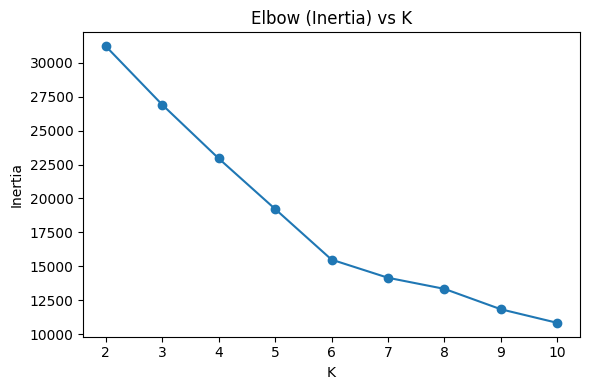

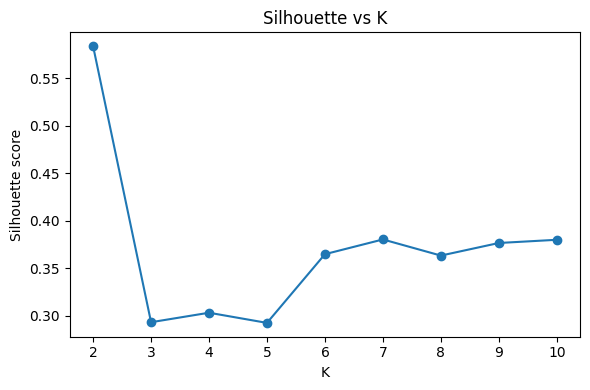

In [41]:
# 6) Choose K using silhouette (with elbow plot for reference)
K_RANGE = range(2, 11)
inertias, sils = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    y = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, y))

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), inertias, marker="o")
plt.title("Elbow (Inertia) vs K")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), sils, marker="o")
plt.title("Silhouette vs K")
plt.xlabel("K"); plt.ylabel("Silhouette score")
plt.tight_layout(); plt.show()

In [42]:
best_k = 6

In [43]:
# 7) Final KMeans fit
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_pca)
df_pat["cluster"] = labels

sil = silhouette_score(X_pca, labels)
dbi = davies_bouldin_score(X_pca, labels)
print(f"[Final KMeans] k={best_k} | silhouette={sil:.4f} | DBI={dbi:.4f}")


[Final KMeans] k=6 | silhouette=0.3649 | DBI=0.9727


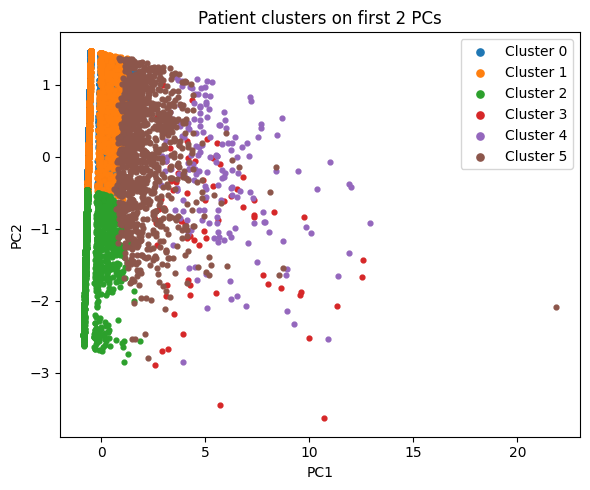

In [44]:
# 8) Quick 2D visualization on first two PCs
plt.figure(figsize=(6,5))
for c in np.unique(labels):
    mask = labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, label=f"Cluster {c}")
plt.title("Patient clusters on first 2 PCs")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=1.5)
plt.tight_layout(); plt.show()

In [45]:
# 9) Numeric profile (cluster-level means in original scales)
#    We inverse only the numeric block back to original units for interpretability.
num_imputer = preprocessor.named_transformers_["num"].named_steps["imputer"]
num_scaler  = preprocessor.named_transformers_["num"].named_steps["scaler"]
num_values  = num_imputer.transform(X[numeric_cols])
num_scaled  = num_scaler.transform(num_values)
num_orig    = num_scaler.inverse_transform(num_scaled)  # returns original units
num_df_orig = pd.DataFrame(num_orig, columns=numeric_cols, index=df_pat.index)

num_profile = num_df_orig.join(df_pat["cluster"]).groupby("cluster")[numeric_cols].mean().round(3)
print("\n=== Numeric profile (cluster means) ===")
display(num_profile)


=== Numeric profile (cluster means) ===


,age,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days
cluster,,,,,
0,72.128,0.281,0.933,0.0,0.704
1,69.752,0.275,0.959,0.0,0.659
2,29.788,0.286,0.845,0.0,0.554
3,55.068,1.699,8.247,0.0,91.575
4,62.859,3.071,60.118,0.0,24.529
5,64.618,2.744,15.640,0.0,10.122


In [46]:
# 10) Categorical distributions per cluster (robust version without column conflicts)
cat_profiles = {}
for c in categorical_cols:
    tmp = df_pat[[c, "cluster"]].copy()
    # counting
    dist = (
        tmp.groupby(["cluster", c])
           .size()
           .to_frame("n")
           .reset_index()
    )
    # within-cluster percentage
    dist["pct"] = dist.groupby("cluster")["n"].transform(lambda s: s / s.sum())
    dist = dist.drop(columns="n")
    cat_profiles[c] = dist

print("\n=== Categorical distribution: PATIENT_SEX ===")
display(cat_profiles["PATIENT_SEX"].sort_values(["cluster", "pct"], ascending=[True, False]))

print("\n=== Categorical distribution: PATIENT_RACE_ETHNICITY ===")
display(cat_profiles["PATIENT_RACE_ETHNICITY"].sort_values(["cluster", "pct"], ascending=[True, False]))



=== Categorical distribution: PATIENT_SEX ===


,cluster,PATIENT_SEX,pct
0,0,Female,1.000000
1,1,Male,1.000000
2,2,Female,0.607649
3,2,Male,0.392351
4,3,Female,0.547945
5,3,Male,0.452055
7,4,Male,0.547059
6,4,Female,0.452941
8,5,Female,0.511604
9,5,Male,0.488396



=== Categorical distribution: PATIENT_RACE_ETHNICITY ===


,cluster,PATIENT_RACE_ETHNICITY,pct
6,0,"White, non-Hispanic",0.905100
0,0,"American Indian or Alaska Native, non-Hispanic",0.063492
3,0,Hispanic,0.012496
2,0,"Black or African American, non-Hispanic",0.006754
1,0,"Asian, non-Hispanic",0.006417
5,0,Unknown/Declined,0.004728
4,0,"Native Hawaiian or Other Pacific Islander, non...",0.001013
13,1,"White, non-Hispanic",0.909651
7,1,"American Indian or Alaska Native, non-Hispanic",0.052704
10,1,Hispanic,0.015058
